#  Titanic Survival Analysis — Exploratory Data Analysis

**Author:** Mansi Kumari
**Tools:** Python · Pandas · Matplotlib · Seaborn

---

## Project Overview

The Titanic dataset is one of the most well-known datasets in data science. It contains information about **891 passengers** who were aboard the RMS Titanic when it sank in April 1912.

###  Objectives
1. Understand the structure and quality of the data  
2. Identify and handle missing values  
3. Explore survival patterns across gender, age, and class  
4. Summarise key findings with clear visualisations  

###  Dataset Source
Built-in dataset via the **Seaborn** library (`seaborn.load_dataset('titanic')`)


## 1. Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print(" Libraries loaded successfully!")


 Libraries loaded successfully!


## 2. Load the Dataset

In [2]:
df = sns.load_dataset('titanic')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 891 rows × 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Data Overview

Before diving into analysis, we inspect data types, basic statistics, and missing values.


In [3]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Summary statistics for numeric columns
df.describe().round(2)


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [5]:
# Summary statistics for categorical columns
df.describe(include='object')


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


## 4. Missing Value Analysis

Understanding missing data is a critical step before any analysis.


In [6]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
missing_df


Columns with missing values:


,Missing Count,Missing %
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


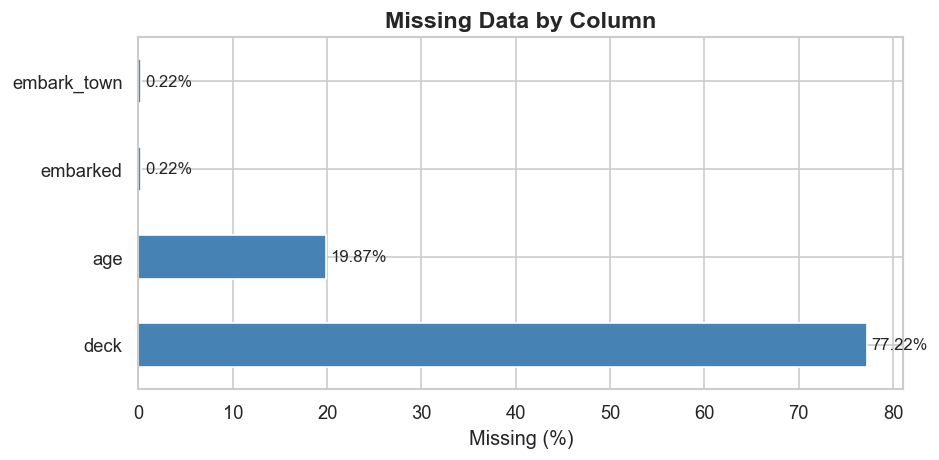

In [7]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()


In [8]:
# Handle missing values
# 'age' → fill with median (less sensitive to outliers)
df['age'].fillna(df['age'].median(), inplace=True)

# 'embarked' → fill with mode (most common port)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# 'deck' has 77% missing → drop it
df.drop(columns=['deck'], inplace=True)

# Confirm no major missing values remain
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n✅ Missing values handled!")


Remaining missing values:
embark_town    2
dtype: int64

✅ Missing values handled!


C:\Users\Mansi\AppData\Local\Temp\ipykernel_26432\628321510.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\Mansi\AppData\Local\Temp\ipykernel_26432\628321510.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

## 5. Univariate Analysis

We examine each key variable individually to understand its distribution.


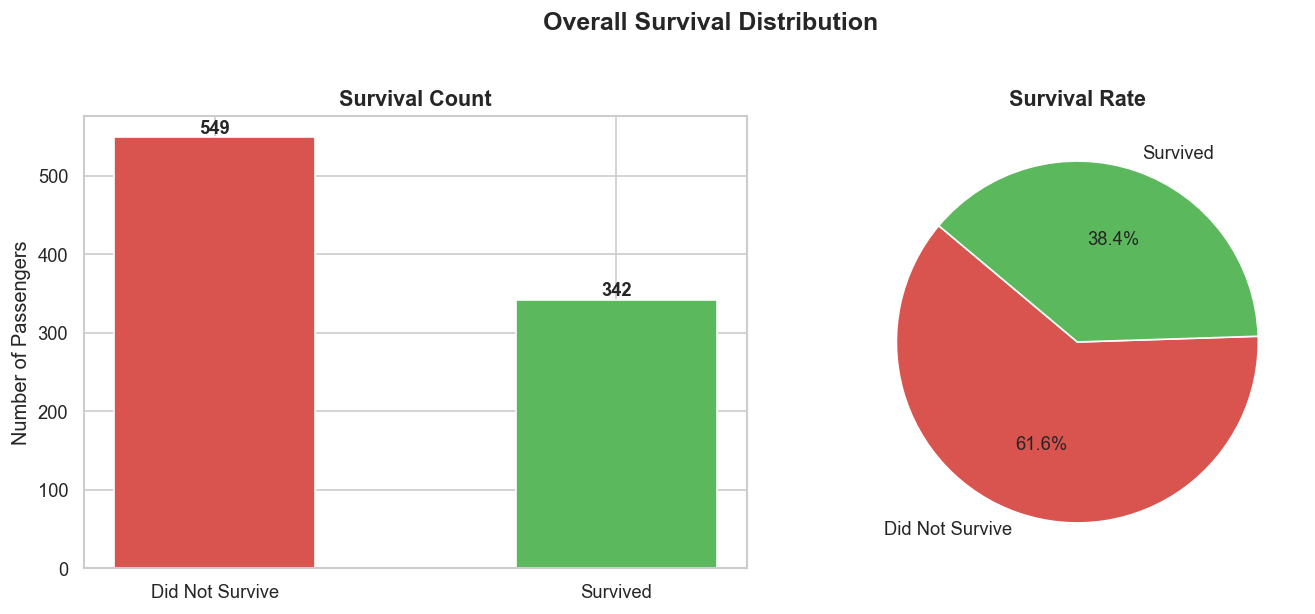


📊 Survival Rate: 38.4%


In [9]:
# Overall survival rate
survival_counts = df['survived'].value_counts()
labels = ['Did Not Survive', 'Survived']
colors = ['#d9534f', '#5cb85c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(labels, survival_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Survival Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(survival_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Survival Rate', fontsize=13, fontweight='bold')

plt.suptitle('Overall Survival Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Survival Rate: {df['survived'].mean()*100:.1f}%")


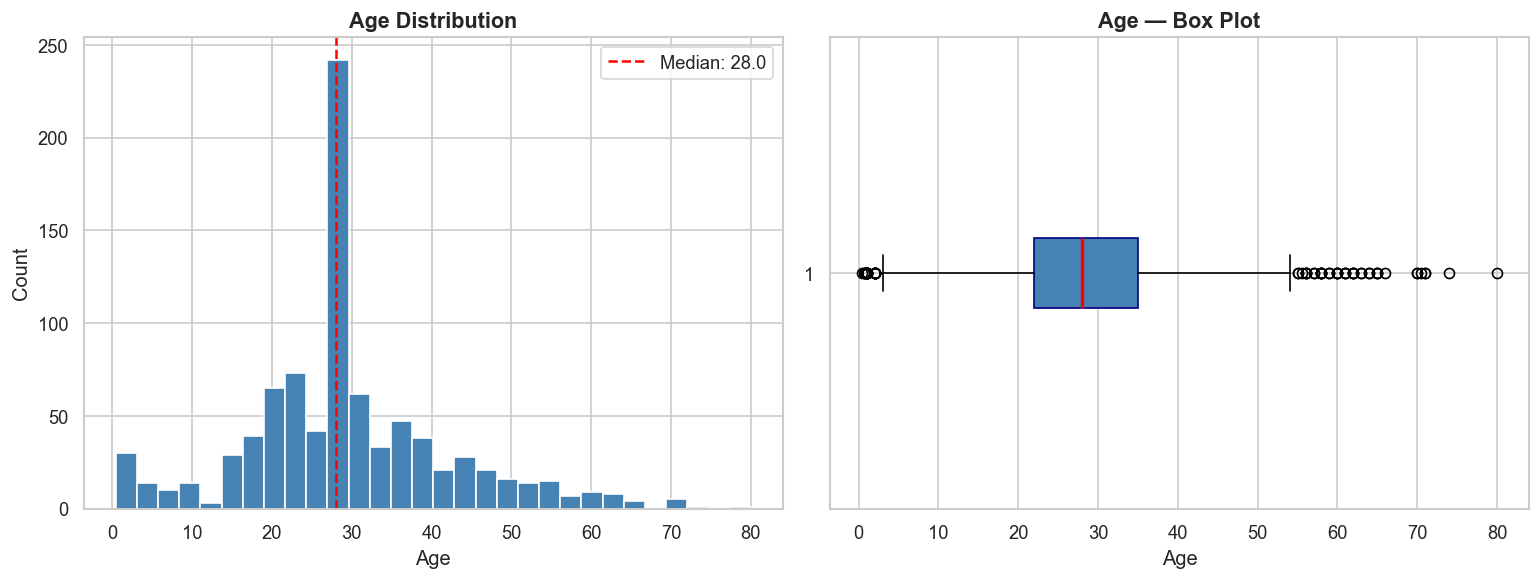

Min Age : 0
Max Age : 80
Mean Age: 29.4
Median  : 28.0


In [10]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['age'].median(), color='red', linestyle='--', label=f"Median: {df['age'].median():.1f}")
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
axes[1].boxplot(df['age'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Age — Box Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print(f"Min Age : {df['age'].min():.0f}")
print(f"Max Age : {df['age'].max():.0f}")
print(f"Mean Age: {df['age'].mean():.1f}")
print(f"Median  : {df['age'].median():.1f}")


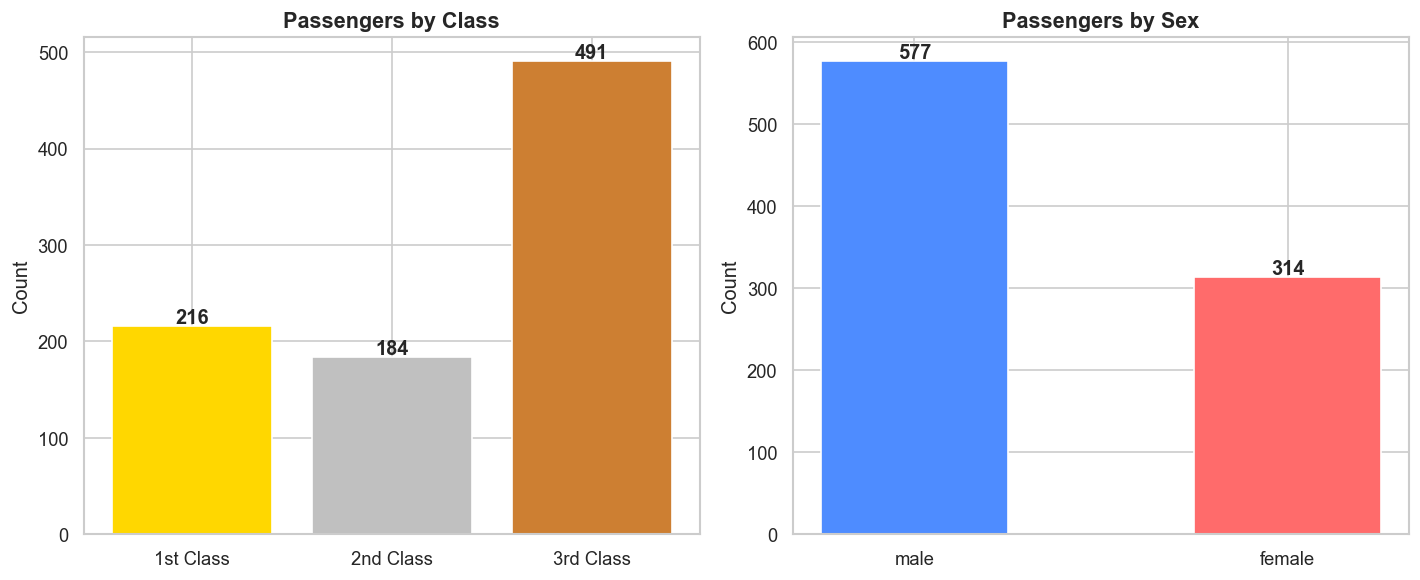

In [11]:
# Passenger class & sex distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Passenger class
pclass_counts = df['pclass'].value_counts().sort_index()
class_labels = ['1st Class', '2nd Class', '3rd Class']
axes[0].bar(class_labels, pclass_counts.values, color=['gold', 'silver', '#cd7f32'], edgecolor='white')
axes[0].set_title('Passengers by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(pclass_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Sex
sex_counts = df['sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['#4e8cff', '#ff6b6b'], edgecolor='white', width=0.5)
axes[1].set_title('Passengers by Sex', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Bivariate Analysis

Now we explore relationships between variables and survival.


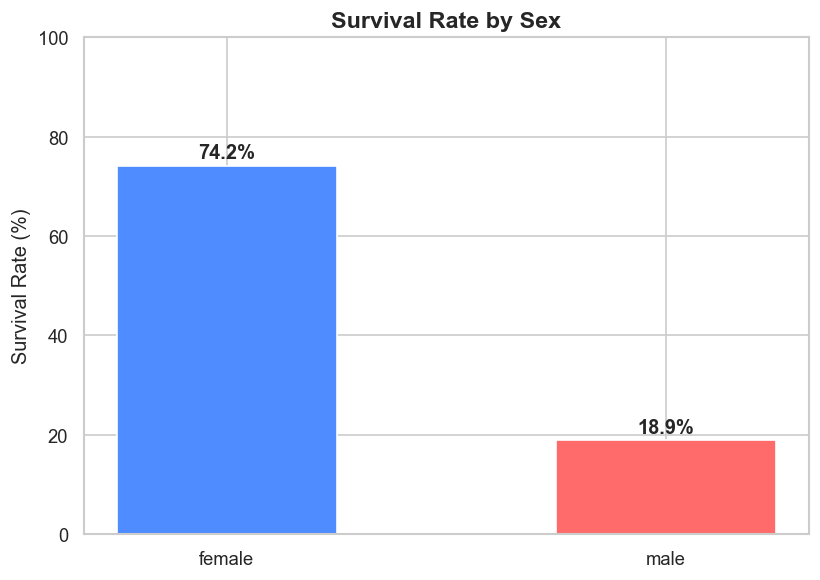

sex
female    74.2
male      18.9


In [12]:
# Survival by Sex
survival_by_sex = df.groupby('sex')['survived'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(survival_by_sex.index, survival_by_sex.values,
              color=['#4e8cff', '#ff6b6b'], edgecolor='white', width=0.5)
ax.set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, survival_by_sex.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(survival_by_sex.round(1).to_string())


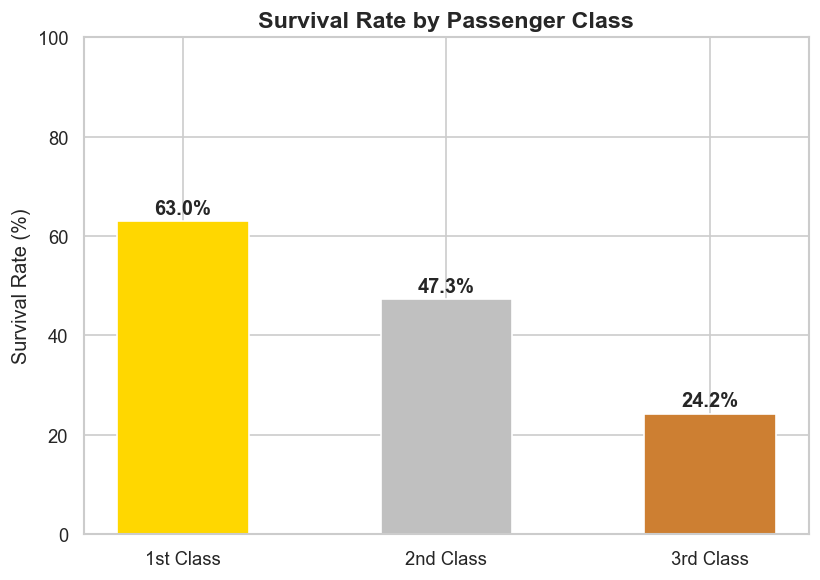

In [13]:
# Survival by Passenger Class
survival_by_class = df.groupby('pclass')['survived'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['1st Class', '2nd Class', '3rd Class'], survival_by_class.values,
              color=['gold', 'silver', '#cd7f32'], edgecolor='white', width=0.5)
ax.set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, survival_by_class.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


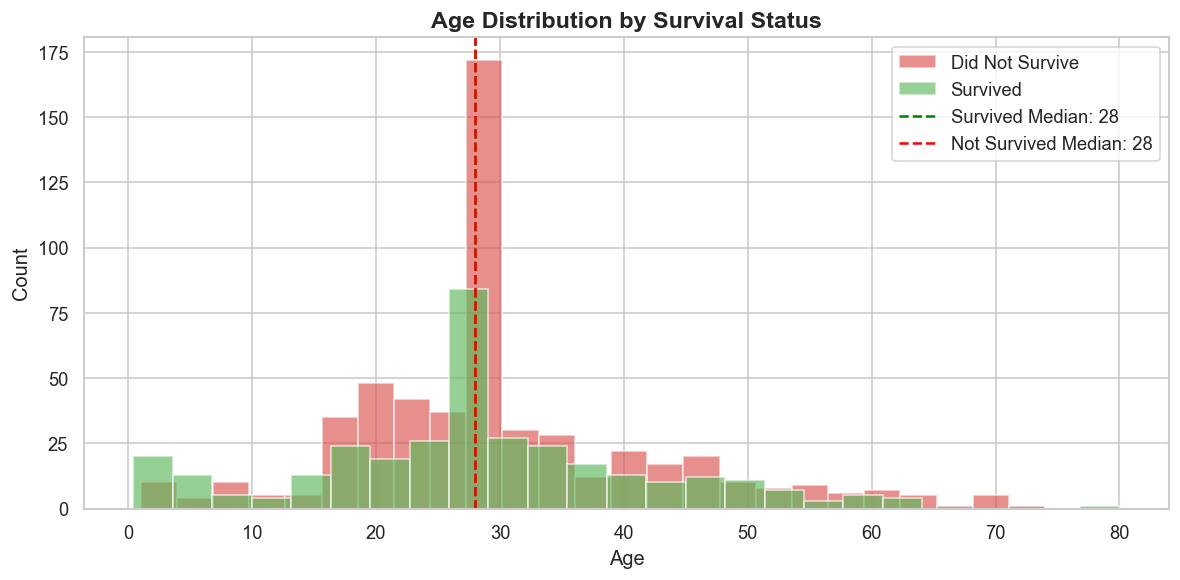

In [14]:
# Age distribution by survival
fig, ax = plt.subplots(figsize=(10, 5))
survived = df[df['survived'] == 1]['age']
not_survived = df[df['survived'] == 0]['age']

ax.hist(not_survived, bins=25, alpha=0.65, label='Did Not Survive', color='#d9534f', edgecolor='white')
ax.hist(survived, bins=25, alpha=0.65, label='Survived', color='#5cb85c', edgecolor='white')
ax.axvline(survived.median(), color='green', linestyle='--', label=f'Survived Median: {survived.median():.0f}')
ax.axvline(not_survived.median(), color='red', linestyle='--', label=f'Not Survived Median: {not_survived.median():.0f}')
ax.set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


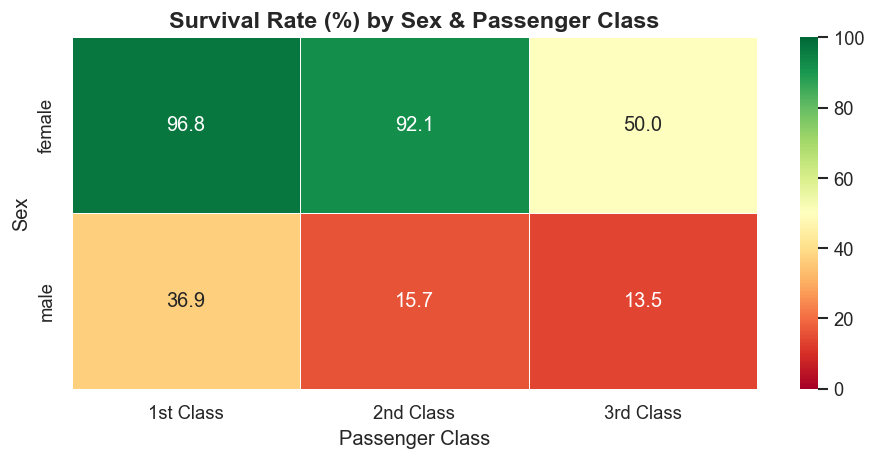

In [15]:
# Heatmap: Sex × Class survival rates
pivot = df.groupby(['sex', 'pclass'])['survived'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            xticklabels=['1st Class', '2nd Class', '3rd Class'],
            annot_kws={'fontsize': 12})
ax.set_title('Survival Rate (%) by Sex & Passenger Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Sex')
ax.set_xlabel('Passenger Class')
plt.tight_layout()
plt.show()


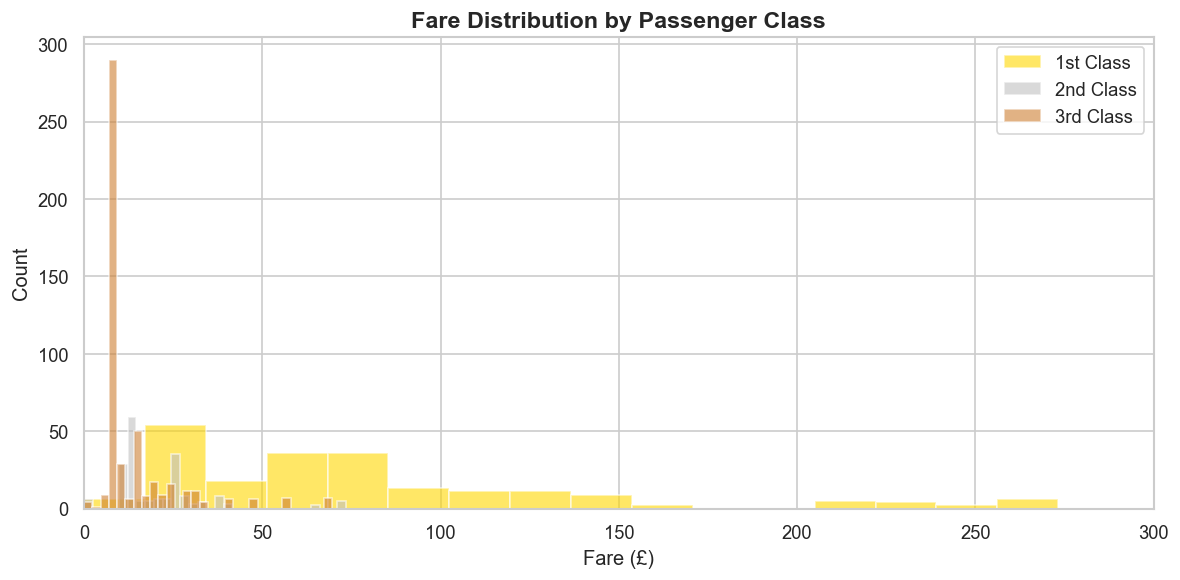

In [16]:
# Fare distribution by class
fig, ax = plt.subplots(figsize=(10, 5))
for pclass, color, label in zip([1, 2, 3], ['gold', 'silver', '#cd7f32'],
                                  ['1st Class', '2nd Class', '3rd Class']):
    data = df[df['pclass'] == pclass]['fare']
    ax.hist(data, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')

ax.set_title('Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Fare (£)')
ax.set_ylabel('Count')
ax.set_xlim(0, 300)
ax.legend()
plt.tight_layout()
plt.show()


## 7. Correlation Analysis

We examine how numeric variables relate to each other.


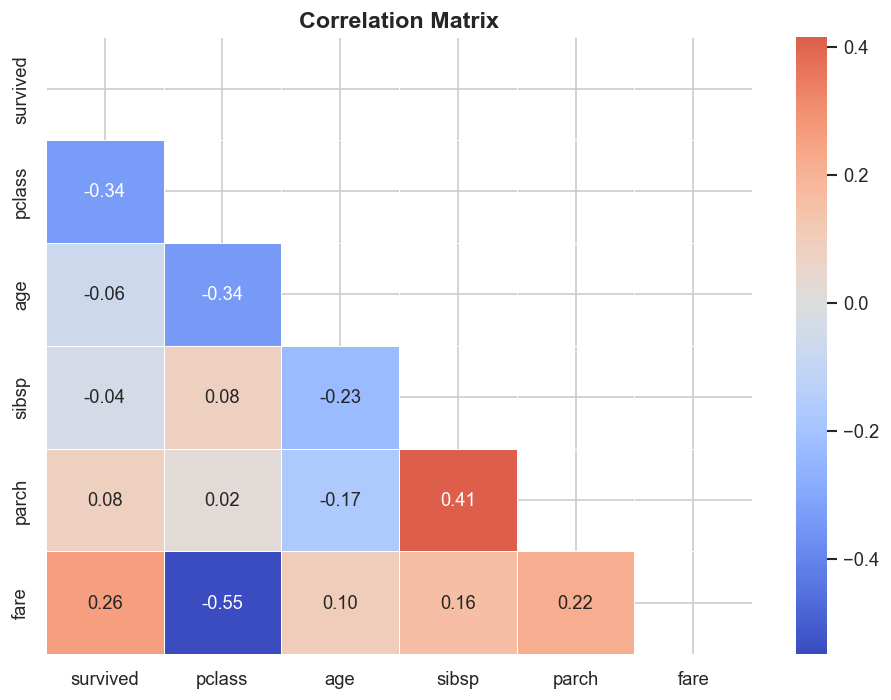


Key correlations with 'survived':
fare      0.257
parch     0.082
sibsp    -0.035
age      -0.065
pclass   -0.338


In [17]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'fontsize': 11})
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey correlations with 'survived':")
print(corr['survived'].drop('survived').sort_values(ascending=False).round(3).to_string())


## 8.  Key Findings & Insights

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **Only 38% of passengers survived** | 342 out of 891 passengers |
| 2 | **Women had a dramatically higher survival rate** | Female: ~74% vs Male: ~19% |
| 3 | **Higher class = higher chance of survival** | 1st: ~63% · 2nd: ~47% · 3rd: ~24% |
| 4 | **1st-class women had the highest survival rate** | ~97% survival rate |
| 5 | **3rd-class men had the lowest survival rate** | ~13% survival rate |
| 6 | **Fare is negatively correlated with class** | 1st class paid significantly more |
| 7 | **Age had a minor positive effect on survival** | Children were slightly more likely to survive |
| 8 | **The "women and children first" protocol is visible in the data** | Confirmed by sex × class heatmap |

---

## 9. Conclusions

This EDA revealed clear social and gender disparities in who survived the Titanic disaster. 
Passenger class and sex were the strongest predictors of survival — reflecting both access 
to lifeboats and the maritime "women and children first" protocol.

**Next steps (if extending this project):**
- Build a logistic regression model to predict survival
- Engineer new features (e.g., family size = SibSp + Parch + 1, title from name)
- Use cross-validation to evaluate model performance
